In [3]:
using JLD2
using Plots

In [4]:
data = jldopen("../output/collated_results.jld2")["results"]

Dict{NTuple{6, Any}, Tuple{Vector, Vector, Int64, Float64}} with 3012 entries:
  ("adv_MWPM", 4, 40, 0.4,… => ([0.0, 0.243747, 0.367431, 0.433749, 0.464885, 0…
  ("adv_MWPM", 16, 160, 0.… => ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0…
  ("adv_MWPM", 12, 120, 0.… => ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0…
  ("adv_MWPM", 16, 160, 0.… => ([0.0, 0.272734, 0.373516, 0.418652, 0.44498, 0.…
  ("adv_MWPM", 12, 120, 0.… => ([0.0, 0.240188, 0.352917, 0.409785, 0.444375, 0…
  ("adv_MWPM", 4, 40, 0.3,… => ([0.0, 0.398834, 0.477429, 0.493612, 0.498349, 0…
  ("basic_MWPM", 12, 120, … => ([0.0, 0.138785, 0.176778, 0.214715, 0.259201, 0…
  ("adv_MWPM", 12, 120, 0.… => ([0.0, 0.0617431, 0.07625, 0.0859931, 0.0891111,…
  ("adv_MWPM", 12, 120, 0.… => ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0…
  ("adv_MWPM", 4, 40, 0.0,… => ([0.0, 0.0584612, 0.06816, 0.0784831, 0.0883844,…
  ("adv_MWPM", 8, 80, 0.15… => ([0.0, 0.0143078, 0.0150266, 0.0165375, 0.017537…
  ("adv_MWPM", 16, 160, 0.… =>

In [5]:
bonus_data = jldopen("bonus_MV.jld2")["MV_data"]

Dict{Tuple{Int64, Int64, Float64, Float64}, Tuple{Vector, Vector}} with 70 entries:
  (24, 240, 0.1, 0.1)   => ([0.0, 0.0333354, 0.0499021, 0.0604497, 0.0683269, 0…
  (32, 320, 0.05, 0.2)  => ([0.0, 0.0496577, 0.0772743, 0.0962733, 0.110715, 0.…
  (32, 320, 0.0, 0.2)   => ([0.0, 0.0271677, 0.0397096, 0.0465818, 0.0508524, 0…
  (24, 240, 0.2, 0.0)   => ([0.0, 0.0578757, 0.0956601, 0.126089, 0.151802, 0.1…
  (32, 320, 0.15, 0.0)  => ([0.0, 0.0265682, 0.040778, 0.0509391, 0.0590904, 0.…
  (32, 320, 0.15, 0.1)  => ([0.0, 0.0620757, 0.0999195, 0.128827, 0.153139, 0.1…
  (32, 320, 0.0, 0.25)  => ([0.0, 0.0508265, 0.0802677, 0.100699, 0.116364, 0.1…
  (28, 280, 0.1, 0.0)   => ([0.0, 0.00850434, 0.0115008, 0.0130338, 0.0138432, …
  (28, 280, 0.1, 0.1)   => ([0.0, 0.0333059, 0.0498083, 0.0604472, 0.0682869, 0…
  (16, 160, 0.05, 0.15) => ([0.0, 0.028557, 0.0418246, 0.0488184, 0.0538937, 0.…
  (20, 200, 0.1, 0.0)   => ([0.0, 0.00860275, 0.0114242, 0.0130552, 0.0139755, …
  (20, 200, 0.1, 0.1)   =

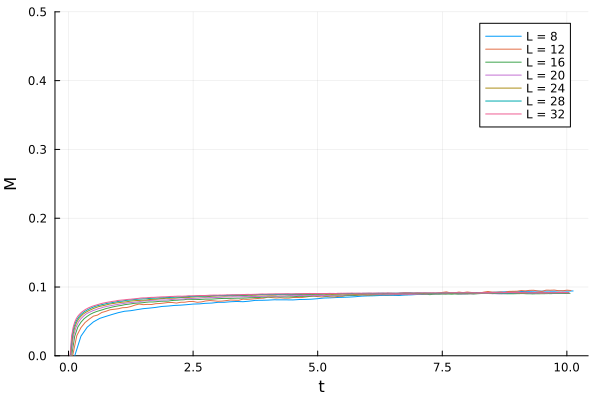

In [4]:
algo = "MV"
p = 0.05
q = 0.15

plt = plot()
for L in 8:4:12
    ys = data[(algo, L, 10L, p, q, NaN)][1]
    xs = 1:length(ys)
    plot!(xs/L, ys, label="L = $L", xlabel="t", ylabel="M")
end

for L in 16:4:32
    ys = bonus_data[(L, 10L, p, q)][1]
    xs = 1:length(ys)
    plot!(xs/L, ys, label="L = $L", xlabel="t", ylabel="M", ylim=(0,0.5))
end

plt

In [5]:
algo = "MV"
p = 0.0

plt = plot()
for L in 8:4:12
    xs = 0.05:0.05:0.25
    ys = [data[(algo, L, 10L, p, x, NaN)][1][L^2\divend] for x in xs]
    plot!(xs, ys, label="L = $L", xlabel="q", ylabel="M", ylim=(0,0.55))
end
for L in 16:4:32
    xs = 0.05:0.05:0.25
    ys = [bonus_data[(L, 10L, p, x)][1][end] for x in xs]
    plot!(xs, ys, label="L = $L", xlabel="q", ylabel="M", ylim=(0,0.55))
end

plt

UndefVarError: UndefVarError: `divend` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

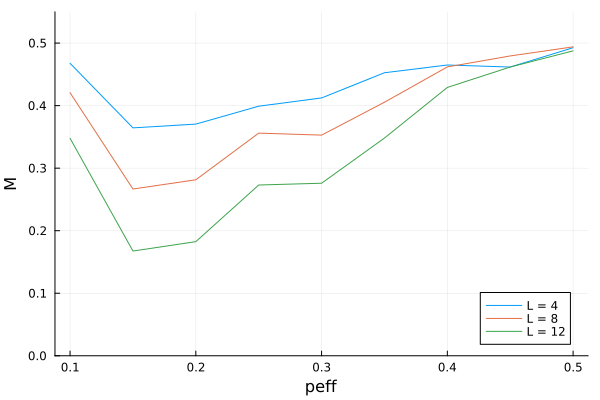

In [17]:
algo = "adv_MWPM"
p = 0.1
q = 0.1

plt = plot()
for L in 4:4:12
    xs = q:0.05:0.5
    ys = [data[(algo, L, 10L, p, q, x)][1][end] for x in xs]
    plot!(xs, ys, label="L = $L", xlabel="peff", ylabel="M", ylim=(0,0.55))
end

plt

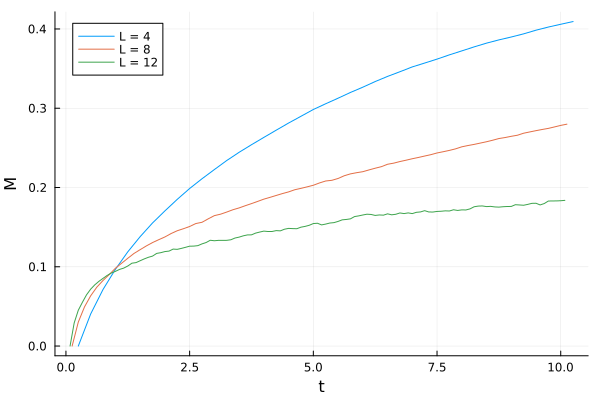

In [267]:
algo = "adv_MWPM"
p = 0.05
q = 0.15
peff = 0.15

plt = plot()
for L in 4:4:12
    ys = data[(algo, L, 10L, p, q, peff)][1]
    xs = 1:length(ys)
    plot!(xs/L, ys, label="L = $L", xlabel="t", ylabel="M")
end

plt

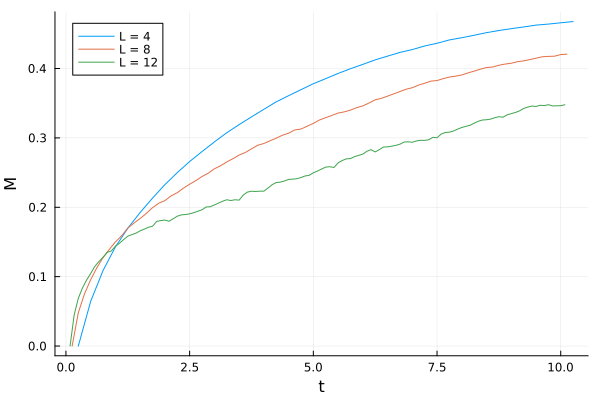

In [309]:
algo = "adv_MWPM"
p = 0.1
q = 0.1
peff = 0.1

plt = plot()
for L in 4:4:12
    ys = data[(algo, L, 10L, p, q, peff)][1]
    xs = 1:length(ys)
    plot!(xs/L, ys, label="L = $L", xlabel="t", ylabel="M")
end

plt

In [13]:
[key for key in keys(data) if key[1] == "adv_MWPM" && key[2] == 12 && key[4] == 0.1 && key[5] == 0.15]

5-element Vector{Tuple{String, Int64, Int64, Float64, Float64, Float64}}:
 ("adv_MWPM", 12, 120, 0.1, 0.15, 0.25)
 ("adv_MWPM", 12, 120, 0.1, 0.15, 0.5)
 ("adv_MWPM", 12, 120, 0.1, 0.15, 0.35)
 ("adv_MWPM", 12, 120, 0.1, 0.15, 0.4)
 ("adv_MWPM", 12, 120, 0.1, 0.15, 0.3)

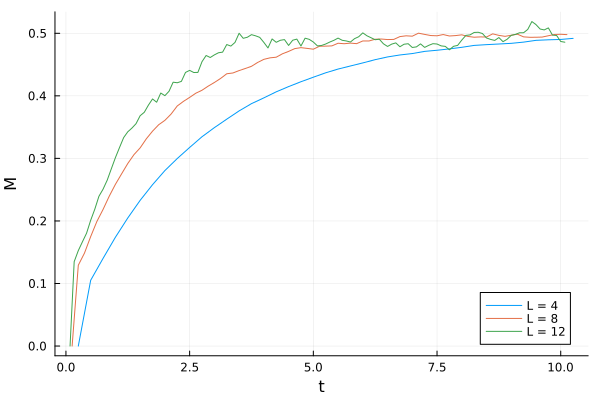

In [208]:
algo = "basic_MWPM"
p = 0.1
q = 0.1

plt = plot()
for L in 4:4:12
    ys = data[(algo, L, 10L, p, q, NaN)][1]
    xs = 1:length(ys)
    plot!(xs/L, ys, label="L = $L", xlabel="t", ylabel="M")
end

plt

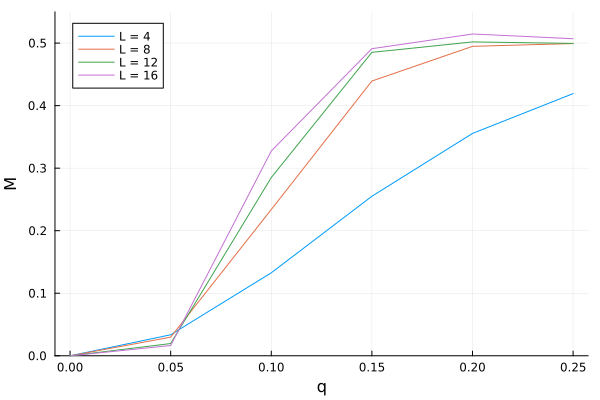

In [12]:
algo = "basic_MWPM"
p = 0.0

plt = plot()
for L in 4:4:16
    xs = 0.00:0.05:0.25
    ys = [data[(algo, L, 10L, p, x, NaN)][1][L] for x in xs]
    plot!(xs, ys, label="L = $L", xlabel="q", ylabel="M", ylim=(0,0.55))
end
plt